# [IAPR][iapr]: Lab 2 ‒ Object description

**Group ID:** 17

**Author 1 (sciper):** Louis Horak (406915)  
**Author 2 (sciper):** Paul Bourgeois (409335)  
**Author 3 (sciper):** Adrien Cheretakis (341744)


**Release date:** 18.03.2026  
**Due date:** 01.04.2026 (11:59 pm)

## Key Submission Guidelines:

- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.
- **You are not allowed to use any libraries** other than those provided in this notebook.
- **TAs must be able to run your code from start to finish without any issues.**
- **Failure to follow these guidelines may result in point deductions** during grading.

[iapr]: https://github.com/LTS5/iapr2025


In [1]:
# Check is at least python 3.9
import sys

assert (sys.version_info.major >= 3) and (sys.version_info.minor >= 9)

In [2]:
# Install required packages
!pip install wget -q
!pip install numpy -q
!pip install matplotlib -q
!pip install scikit-image -q
!pip install scikit-learn -q
!pip install python-mnist -q
!pip install opencv-python -q

In [3]:
# Import main packages
from utils.lab_02_utils import *
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    closing,
    disk,
    opening,
)
from skimage.transform import rotate, resize
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops

import cv2
import numpy as np

---

# Introduction

In this lab, we will work with the famous MNIST dataset. It is composed of thousands of images (size 28x28) that depict handwritten digits from 0 to 9. The code below will automatically download the data from the online repo. This lab aims to create discriminant features from handwritten digits using various approaches.

Take a look at the data to get a better idea of what you will be working within this lab.


Data downloaded under folder: ..\data\data_lab_02
60000 Images and 60000 labels loaded


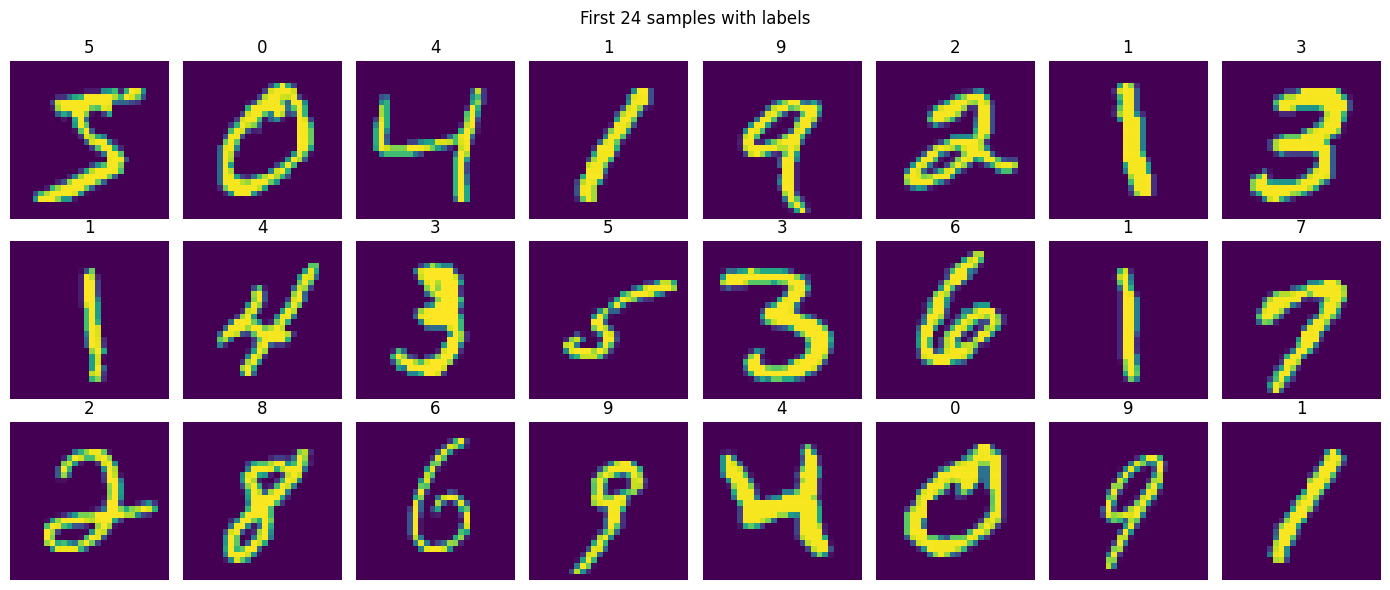

In [4]:
images, labels = load_lab02_data()

---

# Part 1 - Preprocessing [2 pts]

In this lab, we will create different feautre descriptors from digits. However, we will not use all images in the dataset. We will focus on the digits "0" and "5".

## 1.1 Selection (1 pt)

**Q1 (1 pt)** Your first task is to complete the function `extract_label` such that it selects from the input data only the images that are labeled as a given `target_label`. This function will be used to extract 0s and 5s from the data cohort. When running the code, the plots should only show you samples that are 0s (first plot) and 5s (second plot)


In [5]:
def extract_label(images: np.ndarray, labels: np.ndarray, target_label: int):
    """
    The function returns only the images that have target_label as labels.

    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images - handwritten digits
    labels: np.ndarray (N)
        List of labels associated with the input image
    target_label: int
        Selected target label

    Return
    ------
    img_extract: np.ndarray (M, 28, 28)
        Extracted images that have target_label as label (M should be lower than N).
    """
    n, d, _ = np.shape(images)
    M = np.sum(labels == target_label)

    img_extract2 = np.zeros((M, d, d))
    idx = 0
    for k in range(n):
        if labels[k] == target_label:
            img_extract2[idx] = images[k]
            idx += 1
    # ------------------
    # Your code here ...
    # ------------------

    img_extract = images[labels == target_label]

    return img_extract

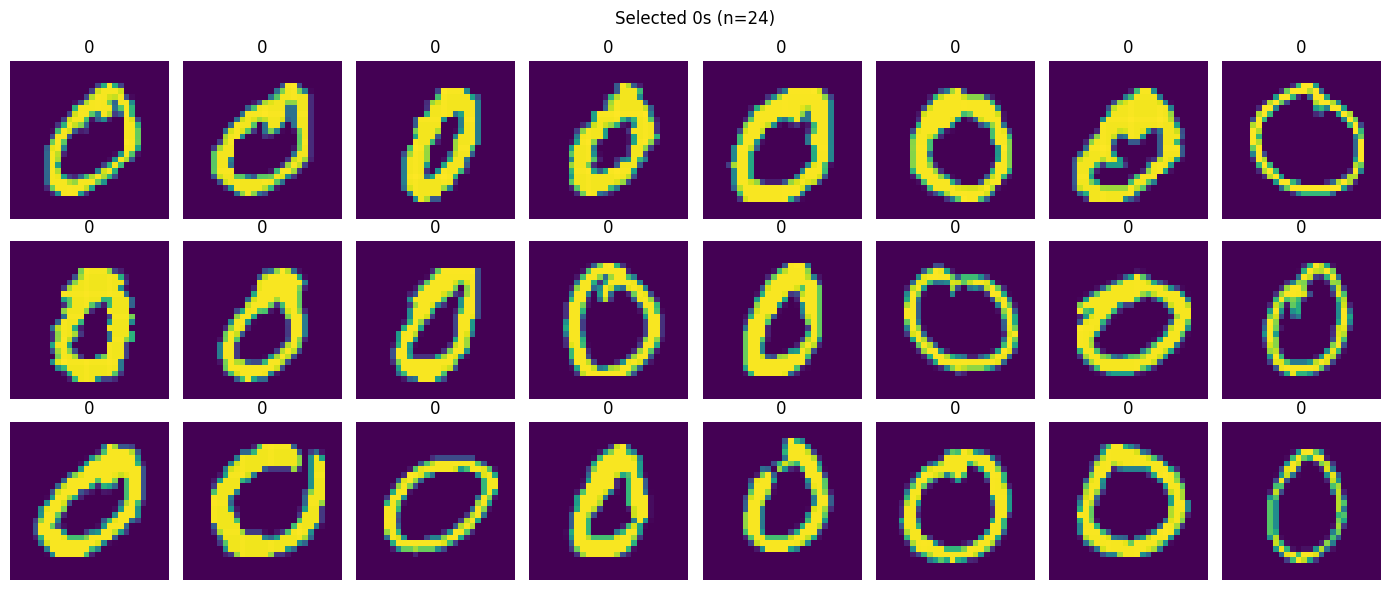

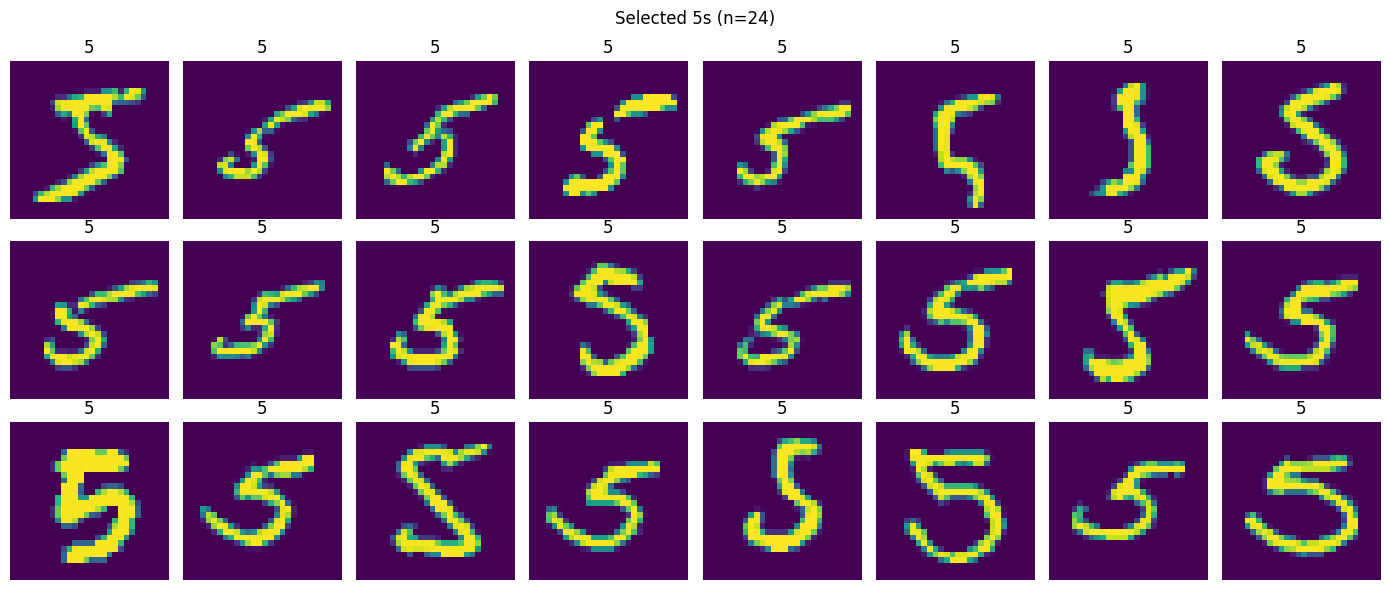

In [6]:
################################################################
############################ TEST ##############################
################################################################

images_a, images_b = test_1_1(extract_label, images, labels)

## 1.2 Preprocessing (1 pt)

Before computing the Fourier descriptors we need to preprocess the images.

- **Q1 (1 pt)**: Complete the function `preprocess` such that it cleans the input images. Take a look at the example images above and try to think what could be improved to allow better uniformity of the data. Take advantage of what you have learned in the previous lab.


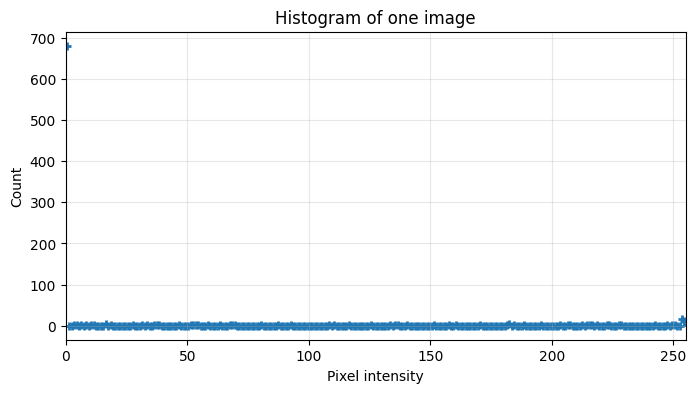

Total count = 784 | Number of pixels = 784


In [7]:
def plot_histogram(image: np.ndarray, bins: int = 256):
    """
    Plot histogram for one given image.

    Args
    ----
    image: np.ndarray (H, W)
        One grayscale image.
    bins: int
        Number of histogram bins.

    Return
    ------
    hist: np.ndarray (bins,)
        Histogram counts.
    bin_edges: np.ndarray (bins + 1,)
        Histogram bin edges.
    """
    import matplotlib.pyplot as plt

    img = image.astype(np.float32).ravel()
    hist, bin_edges = np.histogram(img, bins=bins, range=(0, 256))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(8, 4))
    plt.scatter(bin_centers, hist, lw=2, marker="+")
    plt.title("Histogram of one image")
    plt.xlabel("Pixel intensity")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 255)
    plt.show()

    print(f"Total count = {hist.sum()} | Number of pixels = {image.size}")

    return hist, bin_edges


## Example usage (one image):
_ = plot_histogram(images_b[4])

In [8]:
def preprocess(images: np.ndarray):
    """
    Apply the processing step to images to achieve better data uniformity.

    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images

    Return
    ------
    img_process: np.ndarray (N, 28, 28)
        Processed images.
    """

    # Get the shape of input data and set dummy values
    n, d, _ = np.shape(images)
    img_process = np.zeros_like(images, dtype=np.uint8)

    img_process = (images > 100).astype(np.uint8)
    
    
    for i in range(len(img_process)):
        img_process[i] = closing(img_process[i], disk(1))
    
    pos = [9, 13]
    largeur = 3
    v = 1
    for i in range(largeur):
        for j in range(largeur):
            img_process[3][pos[0]+i, pos[1]+j] = v
    
    return img_process

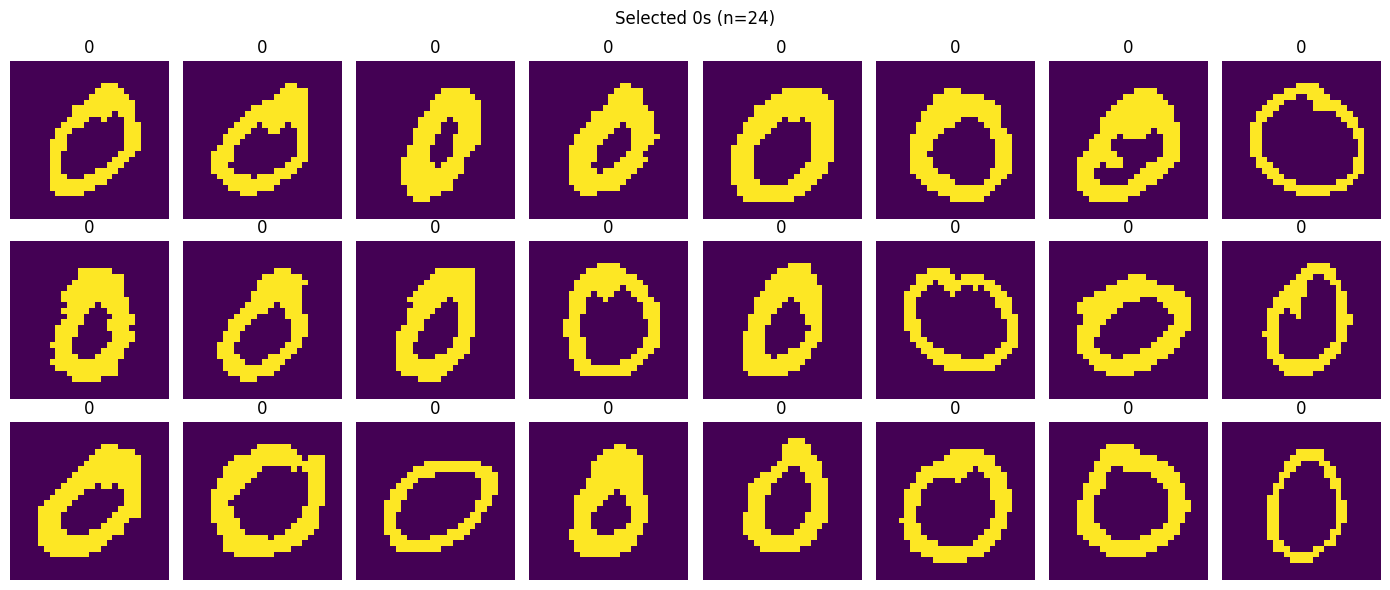

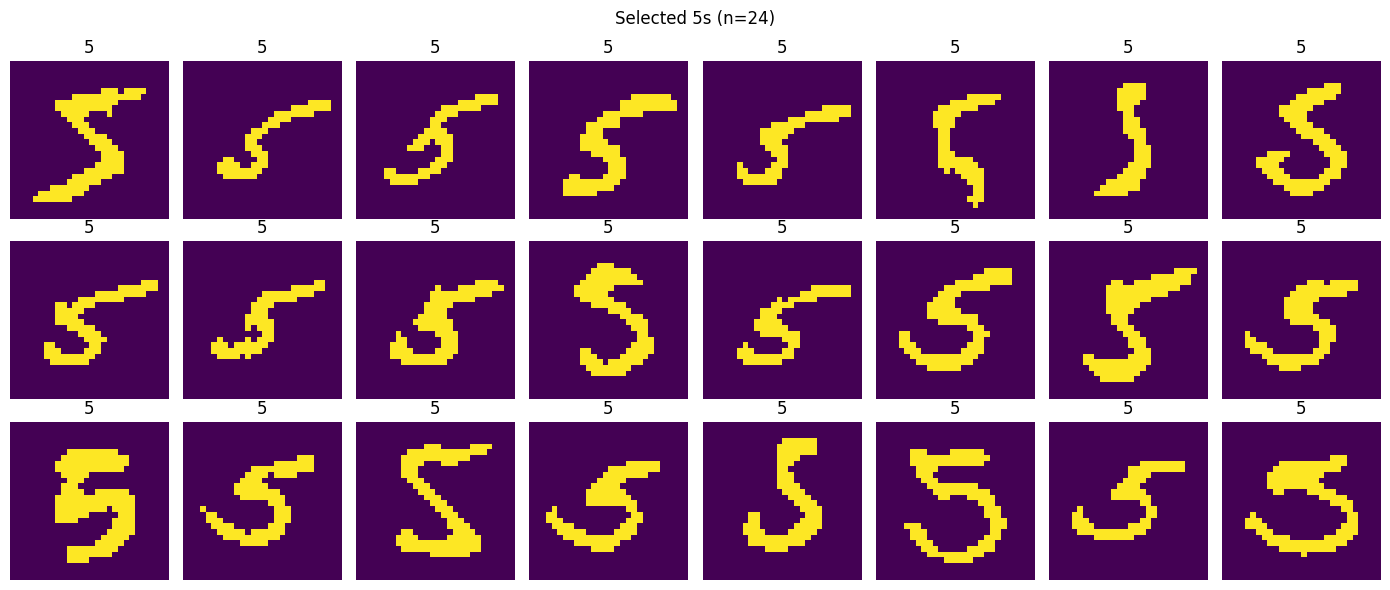

In [9]:
################################################################
############################ TEST ##############################
################################################################

images_p_a, images_p_b = test_1_2(preprocess, images_a, images_b)

---

# Part 2 - Fourier Descriptors [17 pts]

## 2.1. Get contour and descriptors (9 pts)

In this section, we will create Fourier descriptors from digits. The next step in our pipeline will be to detect the contours. To do so you can use existing algorithm available online such as `find_contours`([doc](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.find_contours)) from skcit-image or `findContours` ([doc](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0)) from opencv. Pay attention to the coordinate system when using the contour detection function (is the first component x or y coordinate?).

- **Q1 (2 pts)**: Complete the function `find_contour` below such that it returns the contour estimations of the given images. The provided `display_samples` function will display the returned contours for a subset of images.


In [10]:
def find_contour(images: np.ndarray):
    """
    Find the contours for the set of images

    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images to process

    Return
    ------
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements
        that form the contour.
    """

    # Get number of images to process
    N, _, _ = np.shape(images)
    # Fill in dummy values (fake points)
    contours = [np.array([[0, 0], [1, 1]]) for i in range(N)]
    for i in range(N):
        contours[i], _ = cv2.findContours(
            images[i].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        contours[i] = contours[i][0].squeeze()  # Get the first contour and remove extra dimensions
    # ------------------
    # Your code here ...
    # ------------------

    return contours

1000


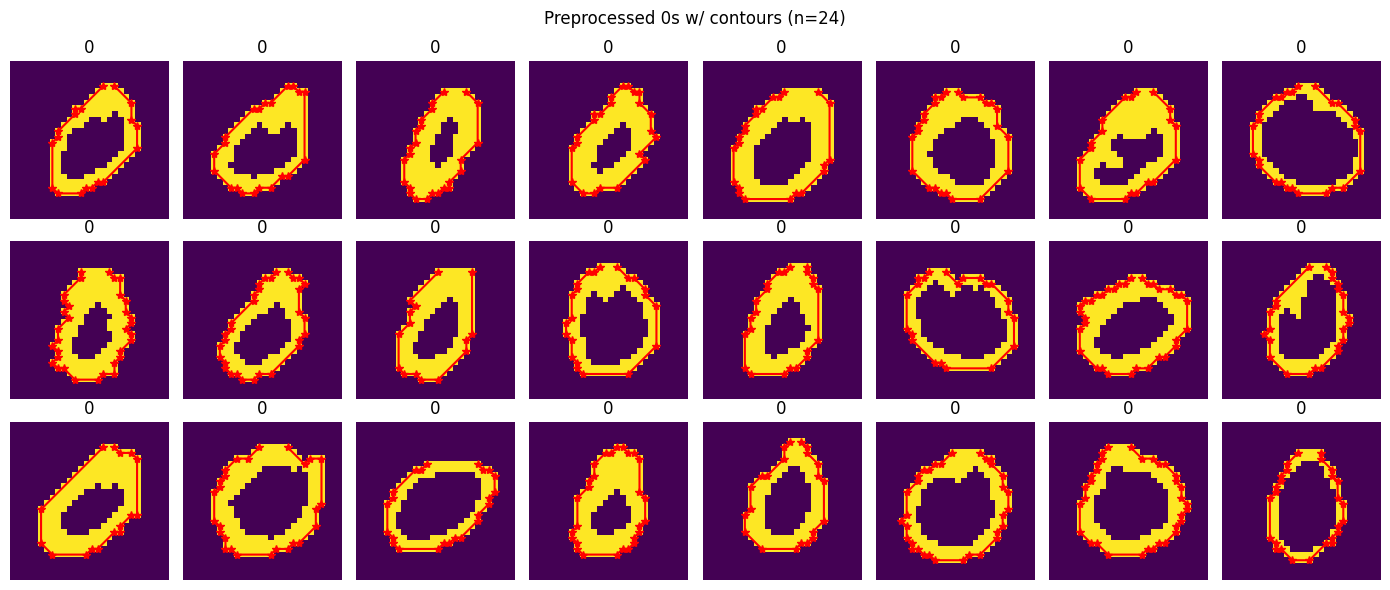

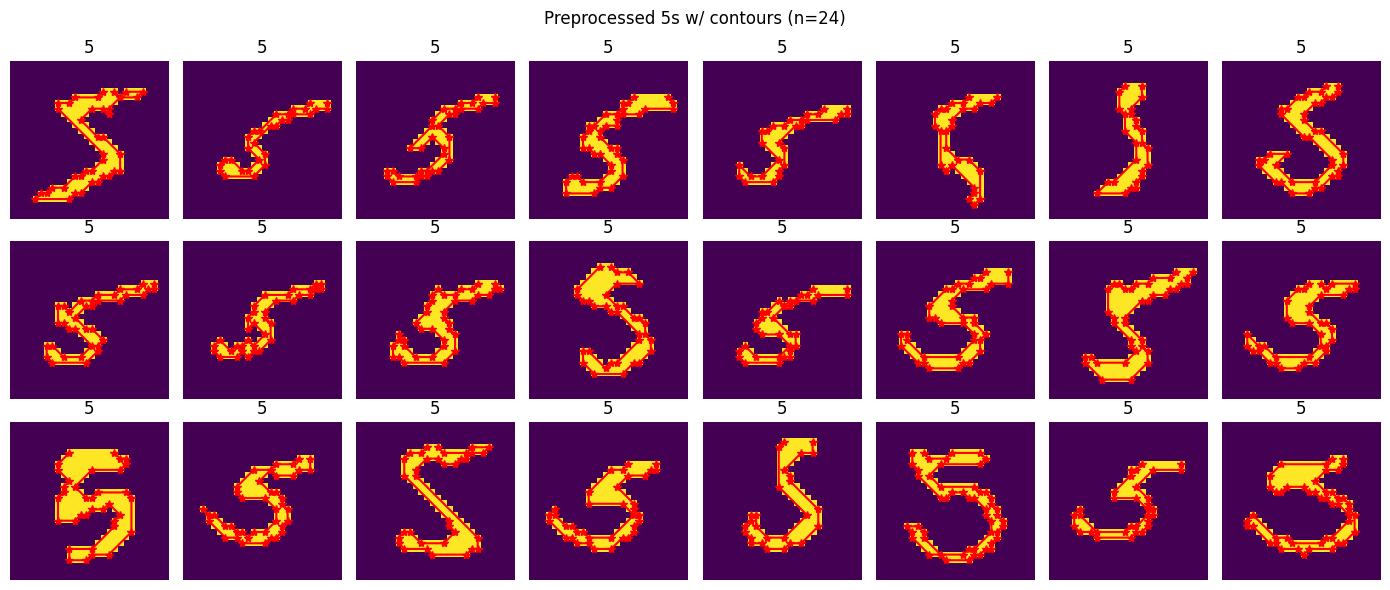

In [11]:
################################################################
############################ TEST ##############################
################################################################

cnt_p_a, cnt_p_b = test_2_1(find_contour, images_p_a, images_p_b)

Now that we are able to properly detect shape contours, we can finally compute Fourier descriptors. However, we still face a small issue. To allow a fair comparison between the Fourier descriptors we need to ensure that all descriptors have the same length.

- **Q2 (2 pts)**: Implement the function `compute_descriptor_padding` that takes as input the computed contours from before and returns the Fourier descriptors for each contour. Use `fft` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)) from Numpy to compute the transformation. Use the `n_sample` argument to set the number of points to consider per contour. If the contour is longer than `n_sample` discard the extra points. If the contour is shorter than `n_sample`, use 0 paddings. Make sure that the first element of the descriptor represent the continuous component in the frequency domain.


In [12]:
def compute_descriptor_padding(contours: np.ndarray, n_samples: int = 11):
    """
    Compute Fourier descriptors of input images

    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements
        that form the contour.
    n_samples: int
        Number of samples to consider. If the contour length is higher, discard the remaining part. If it is shorter, add padding.
        Make sure that the first element of the descriptor represents the continuous component.

    Return
    ------
    descriptors: np.ndarray complex (N, n_samples)
        Computed complex Fourier descriptors for the given input images
    """

    N = len(contours)
    descriptors = np.zeros((N, n_samples), dtype=np.complex128)

    for i in range(N):
        cnt = np.asarray(contours[i])

        # Skip malformed or empty contours and keep zero descriptor.
        if cnt.ndim != 2 or cnt.shape[0] == 0 or cnt.shape[1] < 2:
            continue

        # Keep only x,y coordinates and enforce fixed length using truncate/padding.
        cnt_xy = cnt[:, :2]
        if cnt_xy.shape[0] >= n_samples:
            cnt_fixed = cnt_xy[:n_samples]
        else:
            pad = np.zeros((n_samples - cnt_xy.shape[0], 2), dtype=cnt_xy.dtype)
            cnt_fixed = np.vstack((cnt_xy, pad))

        # Convert contour points to complex sequence and apply FFT.
        signal = cnt_fixed[:, 0].astype(np.float64) + 1j * cnt_fixed[:, 1].astype(
            np.float64
        )
        descriptors[i] = np.fft.fft(signal)

    return descriptors

The code below uses the `plot_features` function to display the computed Fourier descriptors. We display the real, imaginary, and absolute components, respectively. Each color depicts a different digit. We use 2D plots to highlight the clustering capability of the components.

- **Q3 (1 pt)**: Comment on the quality of the Fourier descriptors. Do you think they are good feature descriptors? (justify)
  - **Answer**: In general they are good descriptors. As almost always with Fourier descriptors, we have a huge gain of memory if we compare the space taken by a few descriptors and the one taken by the image we can reproduce out of them. With the first ones, we already have the position and the generall shape of the image, so we can get rid of the highest frequencies to really lower the weight of the information. 
  
    But at this point point, they still present some disadvantadges: 
    - the padding with zeros (if we dont have enough points in the contours). It will obviously produced some error if we don't provide enough contour points
    - they are not invariant for thransformed images. So the descriptors of an image will be very different from the descriptors of the same image after a translation/rotation/zoom.

- **Q4 (1 pt)**: Knowing that we used `n_samples=11` to compute the Fourier transform, what do the components 0, 1, 5, and 10 represent as frequencies? (high, medium, constant, etc.)
  - **Answer**: We know that the the low components refer to the general shape of the image, and the higher components refer to smaller and more precise details. The 0th component codes the mean position of the image, the next ones code the general shape of the image and the higher descriptors code small frequencies, so small details in the contour. This is why if we want to save memory, it is always a better option to get rid of high frequencies descriptors to loose less informations than we would by cutting out small order descriptors.


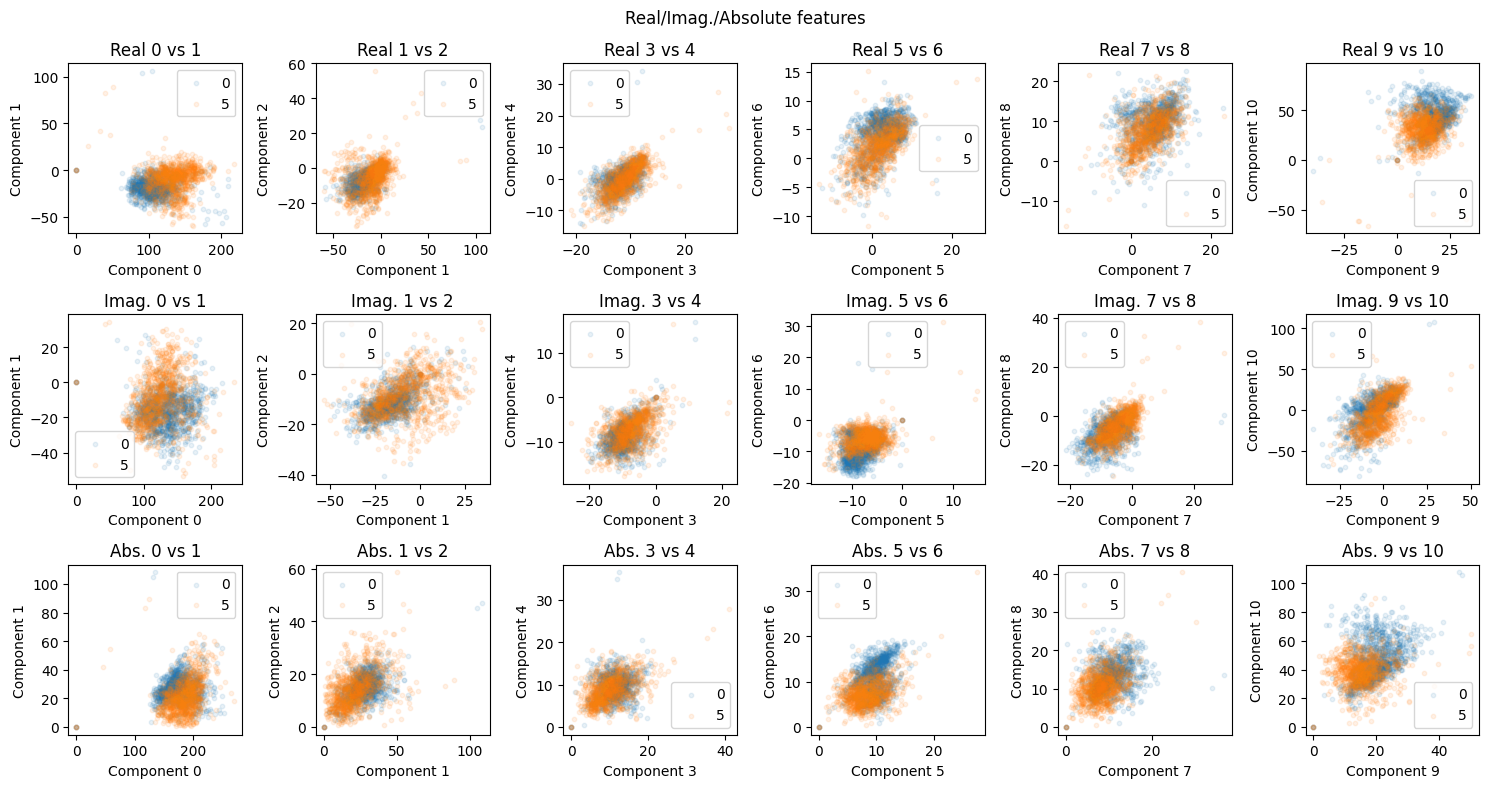

In [13]:
################################################################
############################ TEST ##############################
################################################################

test_2_1_2(compute_descriptor_padding, cnt_p_a, cnt_p_b)

As you might have realized before, the computed Fourier descriptors do not help us to find an optimal separation between the digits. This mainly comes from the fact that using 0 padding is a cheap and inefficient way to ensure homogeneity in length for descriptors. A better solution would be to ensure that we have the same number of points along the contour for each digit. To do so, we need to implement a new function that will resample the contour such that we always have the same number of points no matter the shape.

- **Q5 (2 pts)**: Implement the function `linear_interpolation` that takes as input the contours with various lengths and the wanted number of samples per contour for resampling. For each contour, resample the points such that each contour has the same length `n_samples`. We want the points to be uniformly distributed (same distance between points) along the contour. You can use for example the function `interp` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)) from Numpy to perform the interpolation. The function `display_samples` will display the contour for different lengths.

**Hint**: Think about the contour as two distinct signals x(t) and y(t) that are evaluated at different time steps $t$. Here the time steps can be seen as the Euclidean distance between consecutive samples $t_i$ = $ \sum*{j=1}^{j \leq i} \sqrt{(x*{j} - x*{j-1})^2 + (y*{j} - y*{j-1})^2}$, and $t_0 = 0$. The aim here is to resample the function at new time steps $t_i' = i \ \frac{t*{N-1}}{n*{samples} + 1}$ where $n*{samples}$ is the new number of points.


In [14]:
def linear_interpolation(contours: np.ndarray, n_samples: int = 11):
    """
    Perform interpolation/resampling of the contour across n_samples.

    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements
        that form the contour.
    n_samples: int
        Number of samples to consider along the contour.

    Return
    ------
    contours_inter: np.ndarray (N, n_samples, 2)
        Interpolated contour with n_samples
    """

    N = len(contours)
    contours_inter = np.zeros((N, n_samples, 2))
    for i in range(N):
        cnt = np.asarray(contours[i])

        # Skip malformed or empty contours and keep zero descriptor.
        if cnt.ndim != 2 or cnt.shape[0] == 0 or cnt.shape[1] < 2:
            continue

        # Keep only x,y coordinates and perform linear interpolation.
        cnt_xy = cnt[:, :2]
        x = cnt_xy[:, 0]
        y = cnt_xy[:, 1]
        
        """
        # intuitive step t
        t = np.arange(len(cnt_xy))
        t_inter = np.linspace(0, len(cnt_xy) - 1, n_samples)
        """
        
        # step with the cumulated Euclidean Distance:
        diff = np.diff(cnt_xy, axis=0)
        t = np.concatenate([[0], np.cumsum(np.sqrt((diff**2).sum(axis=1)))])
        t_inter = np.linspace(0, t[-1], n_samples)

        x_inter = np.interp(t_inter, t, x)
        y_inter = np.interp(t_inter, t, y)
        contours_inter[i] = np.stack((x_inter, y_inter), axis=-1)

    # ------------------
    # Your code here ...
    # ------------------

    return contours_inter

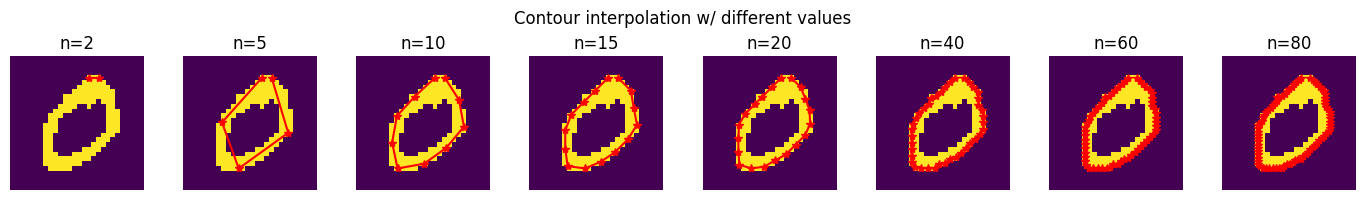

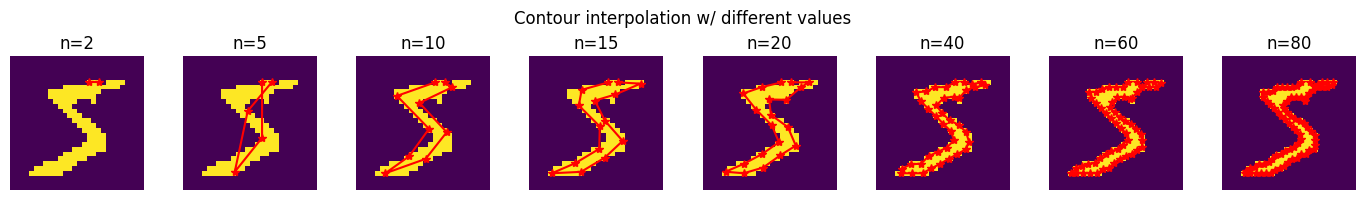

In [15]:
################################################################
############################ TEST ##############################
################################################################

test_2_1_5(linear_interpolation, cnt_p_a, images_p_a)
test_2_1_5(linear_interpolation, cnt_p_b, images_p_b)

Now that we have implemented our resampling approach we can revisualize the clustering efficiency of our descriptors.

- **Q6 (1 pt)**: Comment on the quality of the descriptors. Is it better than before? is there a frequency/component that appears to work better? Does it make sense?
  - **Answer**: In general, the descriptors coding 0's and the ones coding 5's are more clustered. The difference is that with Euclidean Distance approach, we are making sure that the contour points we are looking at are uniformally distributed along the real contour. We note that:
      - the 0th component is now almost at the same position for 0's and 5's. It is not surprising as the mean position of all the contour-points must be more similar across all 0's (resp. all 5's) than when the contour points were not unifomally distributed along the whole contour.
      - for small frequencies : the descriptors are more clustered, as the general shape of a 0 and a 5 is very different.
      - for mid frequencies: we see less compact cluster. These frequencies codes the small details of the contours which can differ between images representing the same number and so, they are not really useful to discriminates 0's and 5's. 
      - higher frequencies: we see more compact clusters again. This is not surprising. 
      - the modulus, for all frequencies: this is where we see the biggest difference between descriptors coding 0's and 5's. Again, we are not surprised as 5's shape are very different from a circle and so, need the high frequencies to "distord" the basis circle, and so, will have high descriptors multiplying the high frequencies. For the opposite reason, the 0's will have low descriptors in front of the high frequencies.


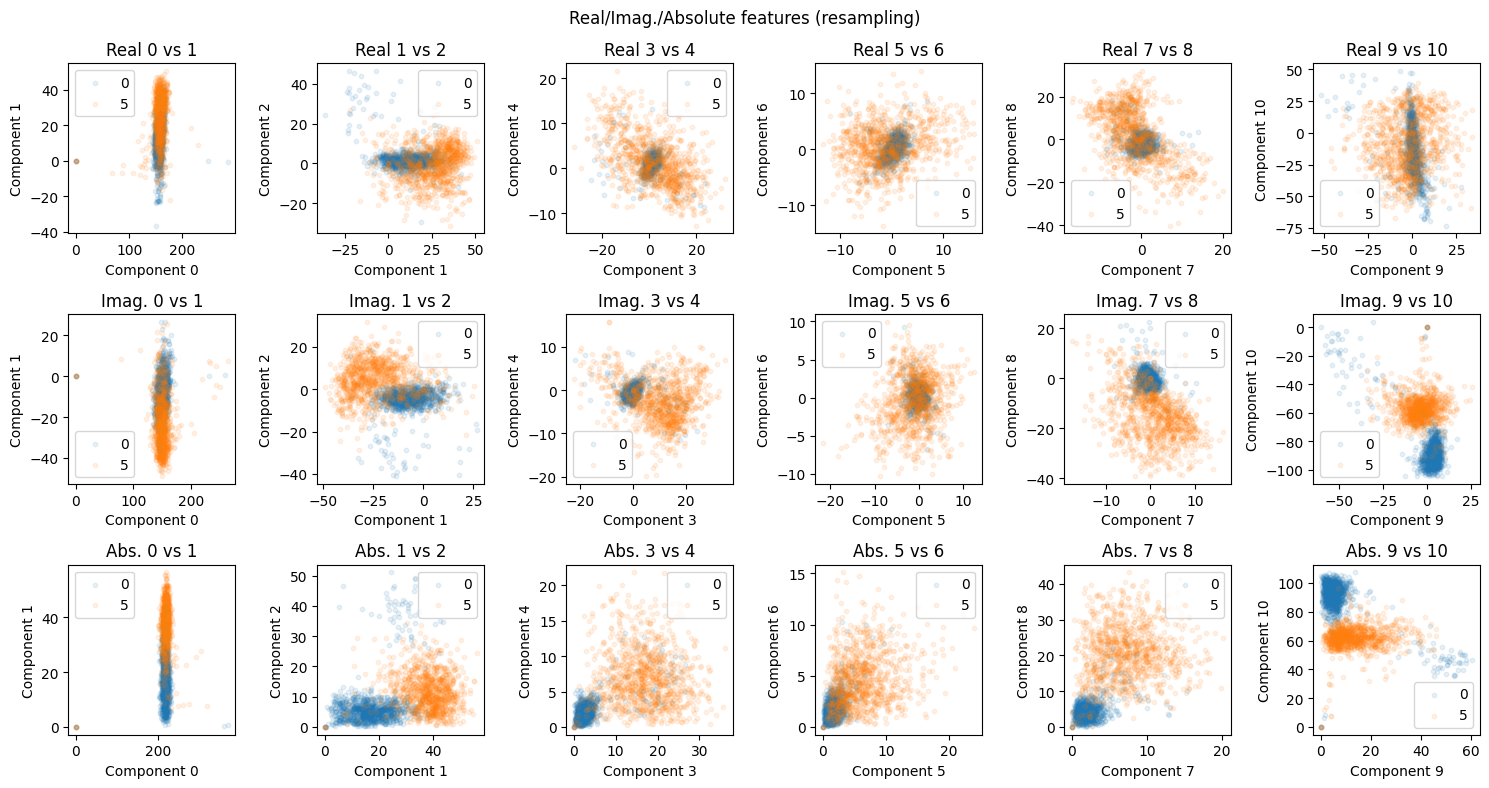

In [16]:
################################################################
############################ TEST ##############################
################################################################

feat_a, feat_b = test_2_1_6(
    compute_descriptor_padding, linear_interpolation, cnt_p_a, cnt_p_b, n_samples=11
)

## 2.2. Reconstruction (2 pts)

For this part, we will now try to go the other way. Given a Fourier descriptor we will try to retrieve the original shape.

- **Q1 (1 pt)** Implement the function `compute_reverse_descriptor` that takes as input a single descriptor and reverses it to x and y coordinates given a number of samples `n_samples`. Use the function `ifft` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html)) from Numpy.


In [17]:
def compute_reverse_descriptor(descriptor: np.ndarray, n_samples: int = 11):
    """
    Reverse a Fourier descriptor to xy coordinates given a number of samples.

    Args
    ----
    descriptor: np.ndarray (D,)
        Complex descriptor of length D.
    n_samples: int
        Number of samples to consider to reverse transformation.

    Return
    ------
    x: np.ndarray complex (n_samples,)
        x coordinates of the contour
    y: np.ndarray complex (n_samples,)
        y coordinates of the contour
    """

    x = np.zeros(n_samples)
    y = np.zeros(n_samples)

    # ------------------
    # Your code here ...
    # ------------------

    # Size normalisation (truncate/pad) as before:
    d = np.asarray(descriptor, dtype=np.complex128).flatten()
    if len(d) >= n_samples:
        d_fixed = d[:n_samples]
    else:
        d_fixed = np.zeros(n_samples, dtype=np.complex128)
        d_fixed[: len(d)] = d

    # iFFT
    contour = np.fft.ifft(d_fixed, n=n_samples)

    # separate x and y
    x = np.real(contour)
    y = np.imag(contour)

    return x, y

With the function `plot_reconstruction` we plot an example of the reconstruction of the digits. We display the result as we progressively add more frequencies. We start with the first component (component 0) and then add frequency pairs from low to high frequencies.

- **Q2 (1 pt)**: Based on your observation, do you think 11 samples are enough to properly describe the digits below? (justify)
  - **Answer**: 
    - With 11 samples, we can produce 11 contours points which are, visually, also enough to describe a 5. We can see that the zigzag-shape already appears around 7 contour points and gets really closer to the wanted contour with 11 samples. So it seems also a good number of samples to describe 5's.
    - As already mention, the circular shape of 0's won't need high frequencies, and definitely not higher frequencies than the needed ones to describe 5's. It means that if 11 samples are enough to describe 5's, that will certainly be the case for 0's as well. Visually, we confirm that even 5 samples seem enough to descibe properly the 0's (so 11 samples are alright and almost "overkill").



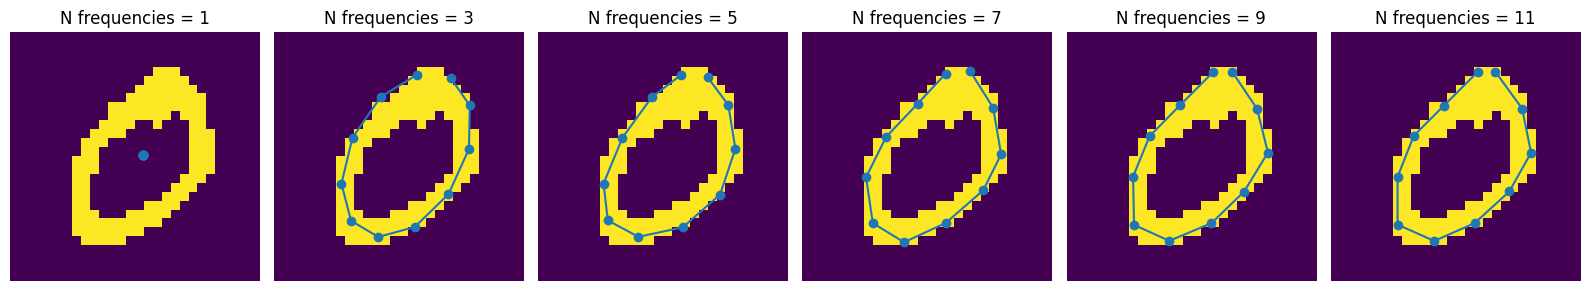

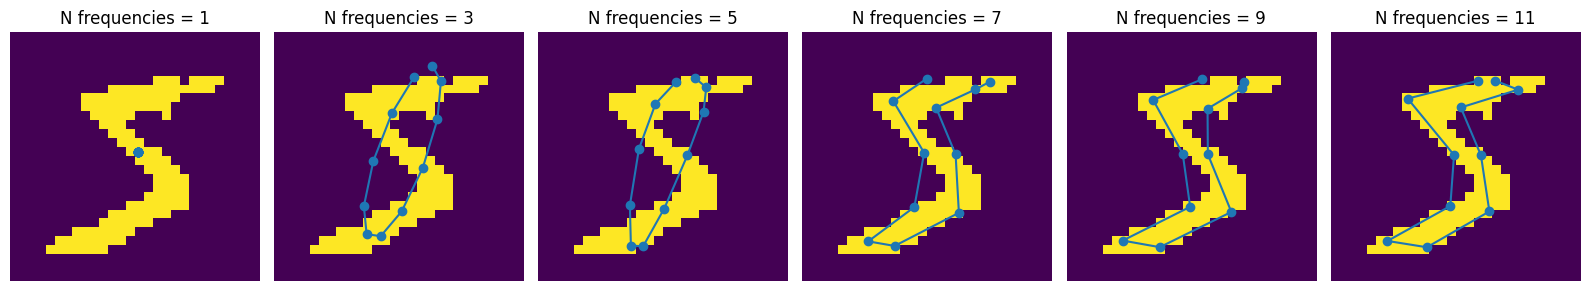

In [18]:
################################################################
############################ TEST ##############################
################################################################

test_2_2(images_p_a, images_p_b, feat_a, feat_b, compute_reverse_descriptor)

## 2.3. Invariance (6 pts)

For the last part with Fourier descriptors, we will check for descriptors invariance. As seen in class, if handled properly Fourier descriptors can be invariant to translation, rotation, and scaling.

- **Q1 (3 pts)**: Implement the functions `apply_rotation`, `apply_scaling`, and `apply_translate` to apply random rotation, scaling, and translation to input images. For scaling and translation, we recommend avoiding large values where the digits are cropped (out of frame). You can use the `random` package ([doc](https://numpy.org/doc/1.16/reference/routines.random.html)) from Numpy to generate random values.


In [19]:
def apply_rotation(img: np.ndarray):
    """
    Apply random rotation to input the image

    Args
    ----
    image: np.ndarray (28, 28)
        Source images

    Return
    ------
    rotated: np.ndarray (28, 28)
        Rotated source images
    """

    rotated = np.zeros_like(img)
    random_angle = np.random.uniform(0, 360)
    # random_angle = np.random.choice([0, 90, 180, 270])
    rotation_matrix = cv2.getRotationMatrix2D((14, 14), random_angle, 1)
    rotated = cv2.warpAffine(img, rotation_matrix, (28, 28), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue = 0)

    # ------------------
    # Your code here ...
    # ------------------

    return rotated


def apply_scaling(img: np.ndarray):
    """
    Apply random scaling to input image
git 
    Args
    ----
    image: np.ndarray (28, 28)
        Source images

    Return
    ------
    scaled: np.ndarray (28, 28)
        Scaled source images
    """

    scaled = np.zeros_like(img)
    random_scale = np.random.uniform(0.5, 1.3)
    scale_matrix = cv2.getRotationMatrix2D((14, 14), 0, random_scale)
    scaled = cv2.warpAffine(img, scale_matrix, (28, 28), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    # ------------------
    # Your code here ...
    # ------------------

    return scaled


def apply_translate(img: np.ndarray):
    """
    Apply random x and y translation to input image

    Args
    ----
    image: np.ndarray (28, 28)
        Source images

    Return
    ------
    translated: np.ndarray (28, 28)
        Translated source images
    """

    translated = np.zeros_like(img)
    
    random_tx = np.random.uniform(-5, 5)
    random_ty = np.random.uniform(-5, 5)

    translation_matrix = np.float32([[1, 0, random_tx], [0, 1, random_ty]])
    translated = cv2.warpAffine(img, translation_matrix, (28, 28), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    # ------------------
    # Your code here ...
    # ------------------

    return translated

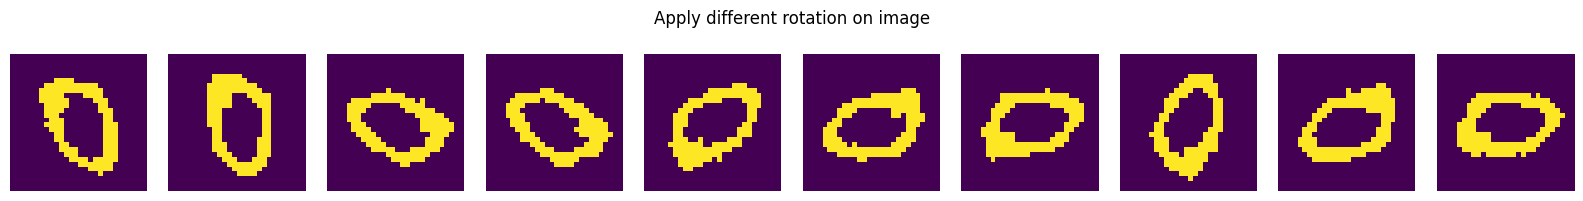

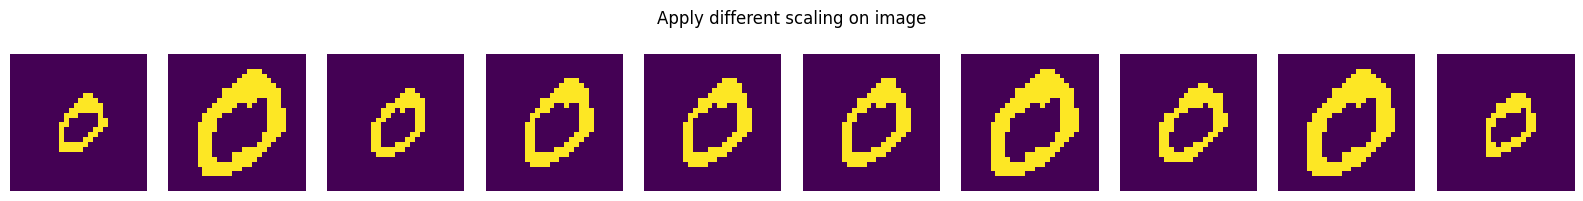

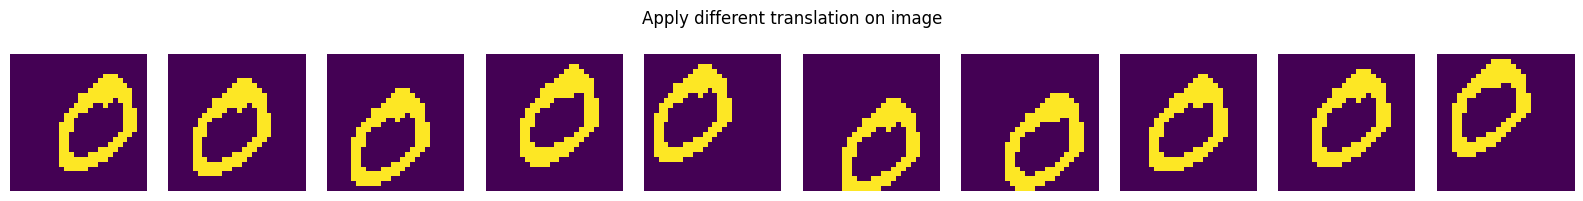

In [20]:
################################################################
############################ TEST ##############################
################################################################

test_2_3(apply_rotation, apply_scaling, apply_translate, images_p_a[0])

Now that we implemented our transformation, we can test for feature invariance. To assess the robustness of the Fourier descriptors to image transformations, we compute the error between the original descriptors (before transformation) to the one after transformation.

- **Q2 (1 pt)**: Complet the function `translation_invariant` to make the Fourier deciptor invariant to translation. Does the error decrease after treatment for translation invariance? Is it null, if not why?
  - **Answer**: The course taught us that the fourier descriptors of an image and the ones of the same image after a translation are the same, except for the 1st one (the descriptor of index 0). It is not surprising as this descriptor multiplies the frequency 0, it is related tp the central position of the contour, which is precisely what we change with a translation.  

    Thus we decide to attribuate the same value to the 1st descriptor of each image (we chose 0 to get rid of any position-information), so this modified descriptor won't be accounted in the error. 
    
    In practical, we see a huge improvement in the error which tells us that this is a good method. The remaining error may be due to the linear interpolation that always causes some small numerical errores.

In [21]:
def translation_invariant(features):
    """
    Make input Fourier descriptors invariant to translation.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to translation of N images
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)

    # ------------------
    # Your code here ...
    # ------------------

    N, D = features.shape

    for i in range(N):
        features_inv[i] = features[i]
        features_inv[i, 0] = 0

    return features_inv

Translation error: 4.74
Corrected translation error: 0.91


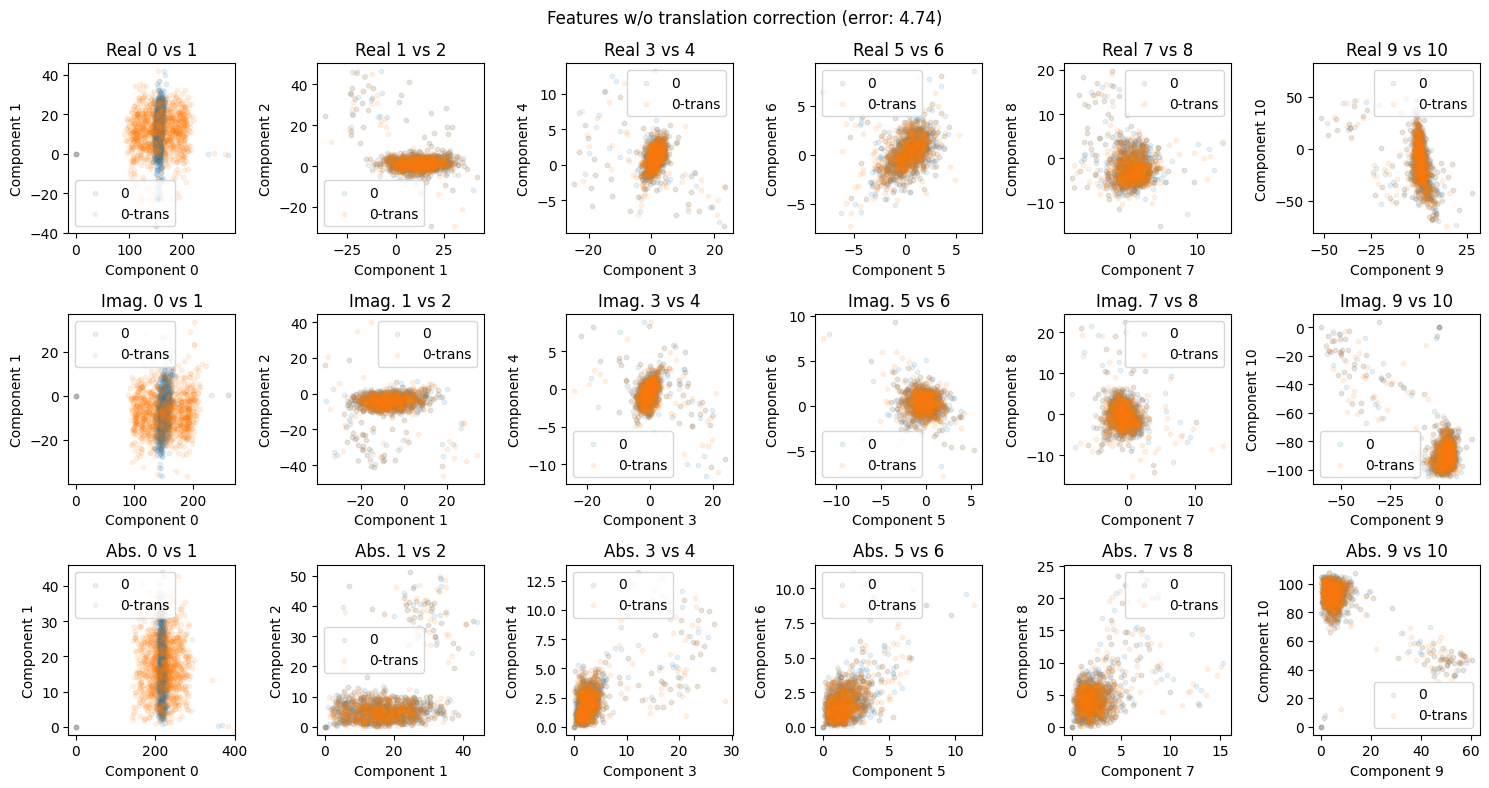

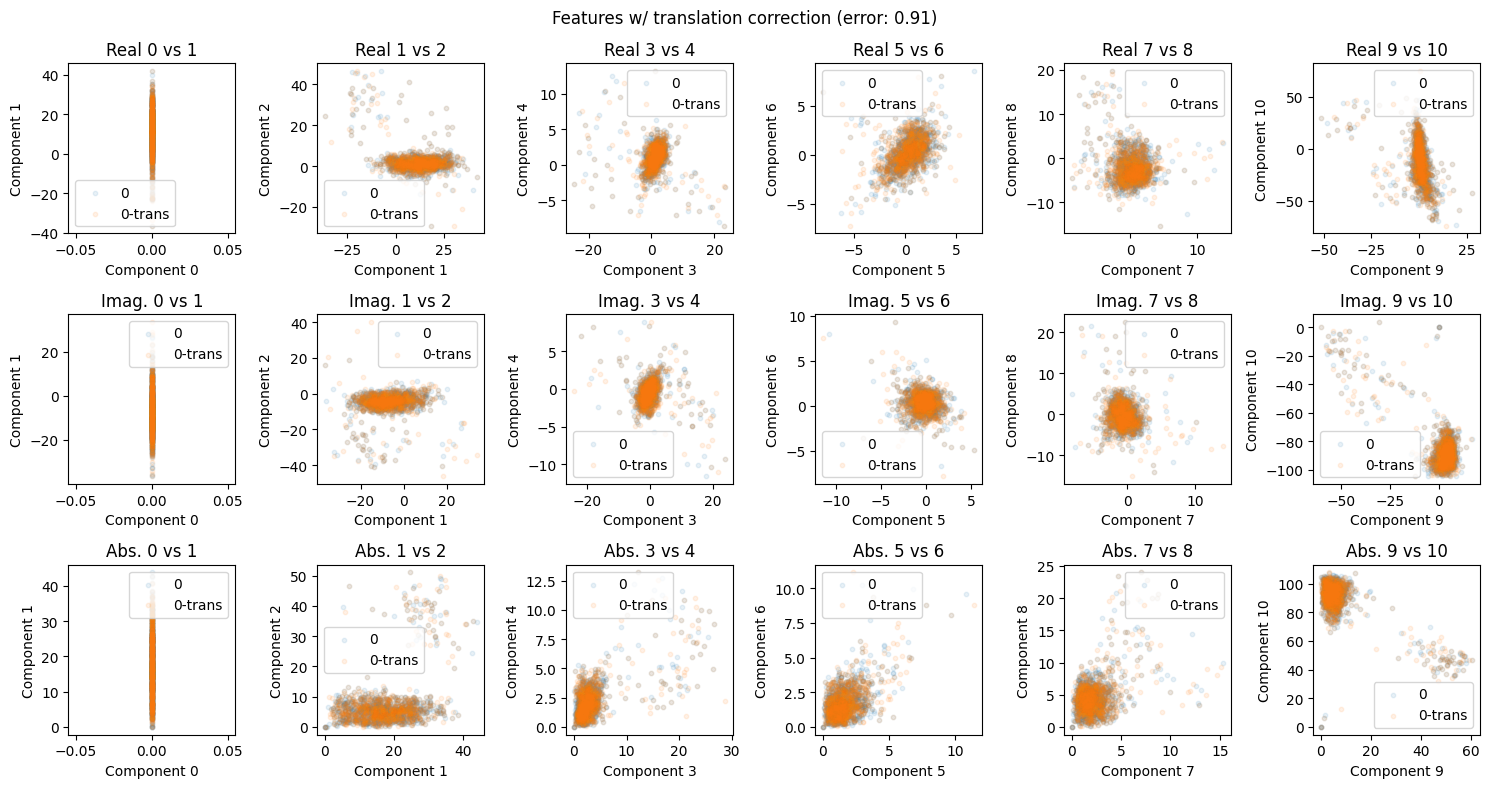

In [22]:
################################################################
############################ TEST ##############################
################################################################

feat_t_a = test_2_3_2(
    translation_invariant,
    find_contour,
    apply_translate,
    compute_descriptor_padding,
    linear_interpolation,
    images_p_a,
    feat_a,
)

- **Q3 (1 pt)**: Complet the function `rotation_invariant` to make the Fourier deciptor invariant to rotation. Does the error decrease after treatment for rotation invariance? Do you think that selecting specific rotation angles might help the error to decrease even lower?
  - **Answer**: We know from the course that a rotation will only affect the phase of the fourier deciptors. This is why we erease all the information concerning the phase and this is achieved by only taking the modulus of each descriptor.

    Obviously, the imaginary part, after invariance treatment is null, and the new real part is equal to the new modulus which is also equal to the old modulus.

    The error did really decrease but is still around 25% of its value without invariance treatment. This may be also due to the linear approximation already mentionned. We noted that if the rotation angle is a multiple of $\pi$/2, the error is significantly minimised. This may be due to the fact that with such a rotation, the new pixel will precisely be at the position of one "case" in the grid 28x28. With rotation of other angles, the new pixel might be at the intersection of 2 or 4 "cases" and then gets attributed one case. So, the result is not exactly the same image after a translation.


In [23]:
def rotation_invariant(features):
    """
    Make input Fourier descriptors invariant to rotation.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to rotation of N images
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)

    # ------------------
    # Your code here ...
    # ------------------        
     
    N, D = features.shape
    for i in range(N):

        features_inv[i] = abs(features[i])

    return features_inv

Rotation error: 8.65
Corrected rotation error: 2.28


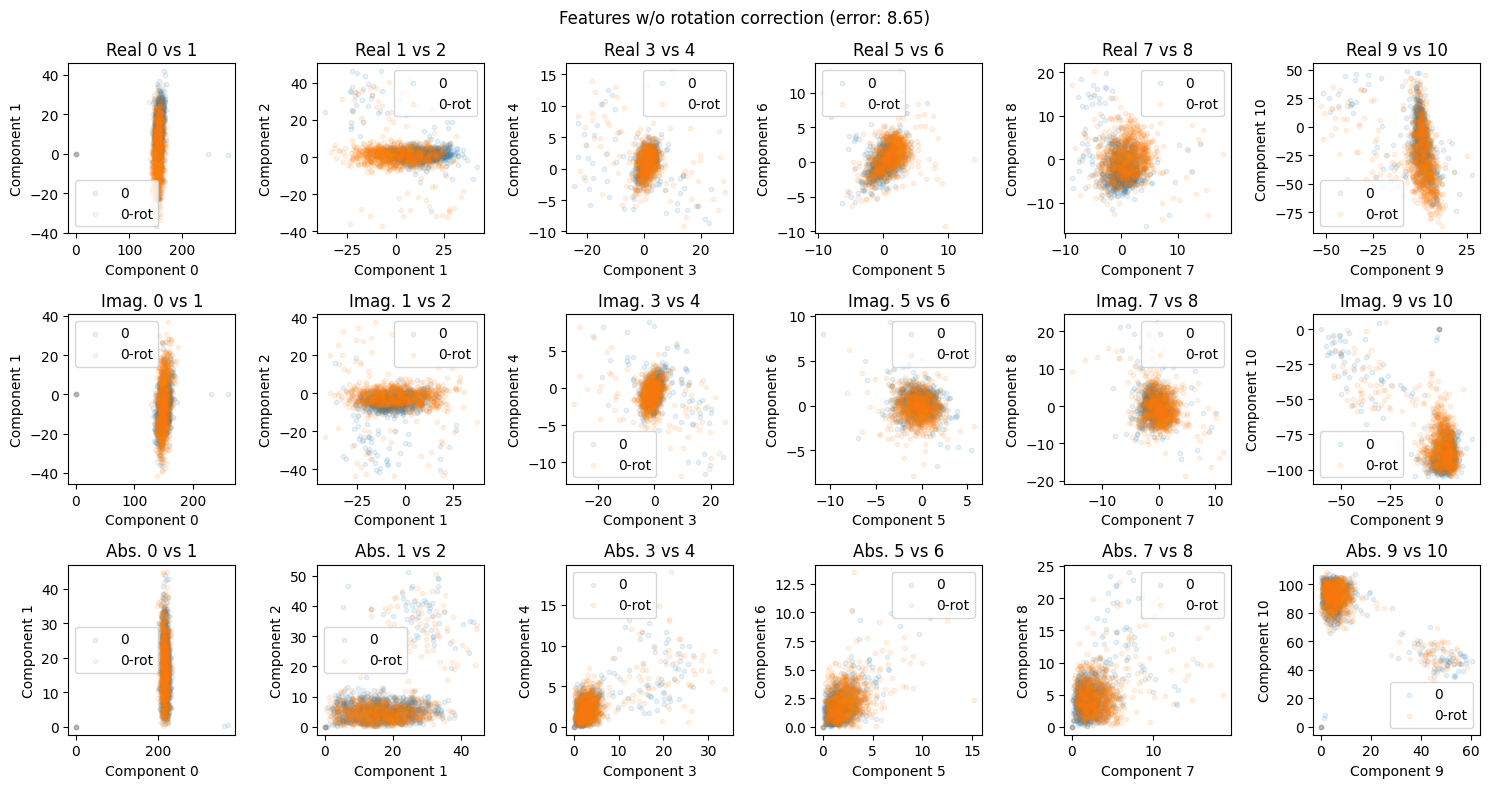

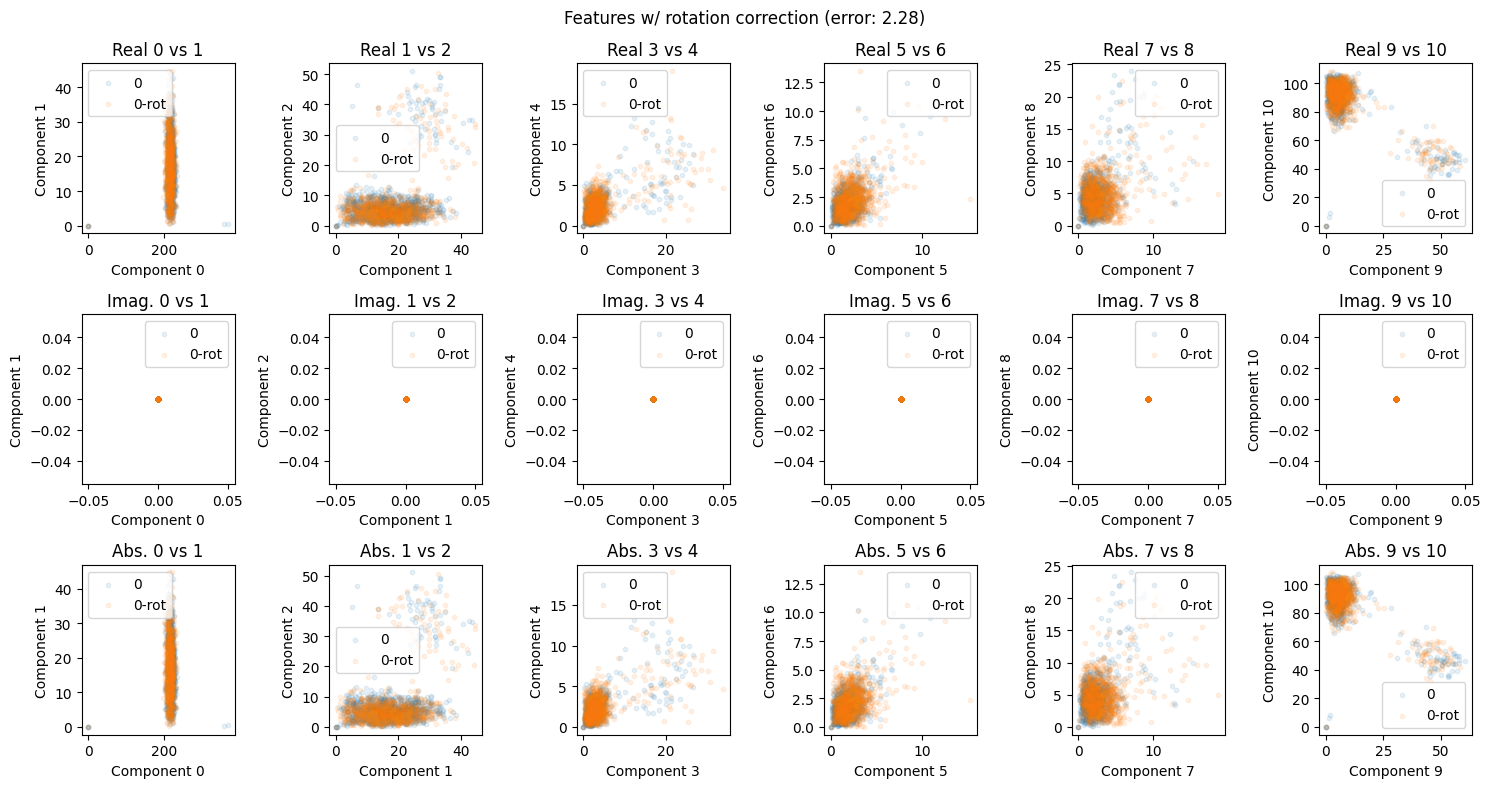

In [24]:
################################################################
############################ TEST ##############################
################################################################

test_2_3_3(
    rotation_invariant,
    find_contour,
    apply_rotation,
    compute_descriptor_padding,
    linear_interpolation,
    images_p_a,
    feat_a,
)

- **Q4 (1 pt)**: Complet the function `scaling_invariant` to make the Fourier deciptor invariant to scaling. Does the error decrease after treatment for scaling invariance? Is it null? Why?
  - **Answer**: We learned from the course that an image after being scalled will see all its descriptors multiplied by the one factor. This means that the ratio between each of them is preserved. 

    We decided to choose one descriptor and to use its modulus as a reference. The ratio between all the descriptors and the reference (including the chosen descriptor) must not be changed by a scalling of the image. We first wanted to choose the descriptor [0] but this descriptor is really bigger than the others (as it needs to show the middle of the image). It almost assign 0 to the other descriptors which then shows an artificially low error. So we choosed the second descriptor (descriptor[1]) which is smaller.

    Indeed, this method does minimise the error, and the remaining error is probably due to the usual factors already mentionned (linear interpolation).

In [25]:
def scaling_invariant(features):
    """
    Make input Fourier descriptors invariant to scaling.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to scaling of N images
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)

    # ------------------
    # Your code here ...
    # ------------------

    N, D = features.shape

    for i in range(N): 

        ratio = np.abs(features[i, 1]) # coeff0 refers to the centroid, coeff 1 refers to the global shape
        if ratio < 1e-8:
            ratio = 1e-8

        features_inv[i] = features[i] / ratio

    return features_inv

Scaling error: 4.74
Corrected scaling error: 1.01


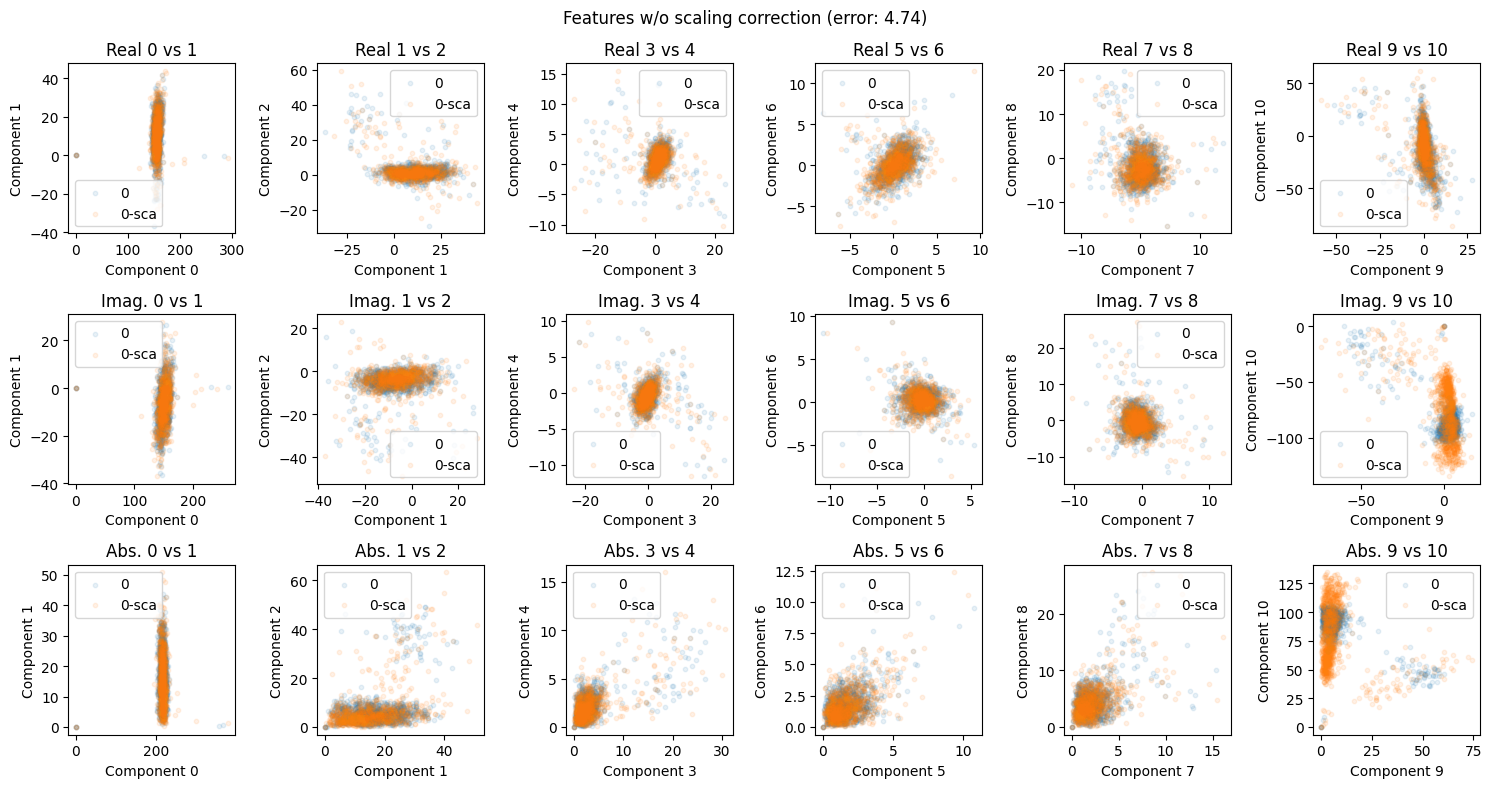

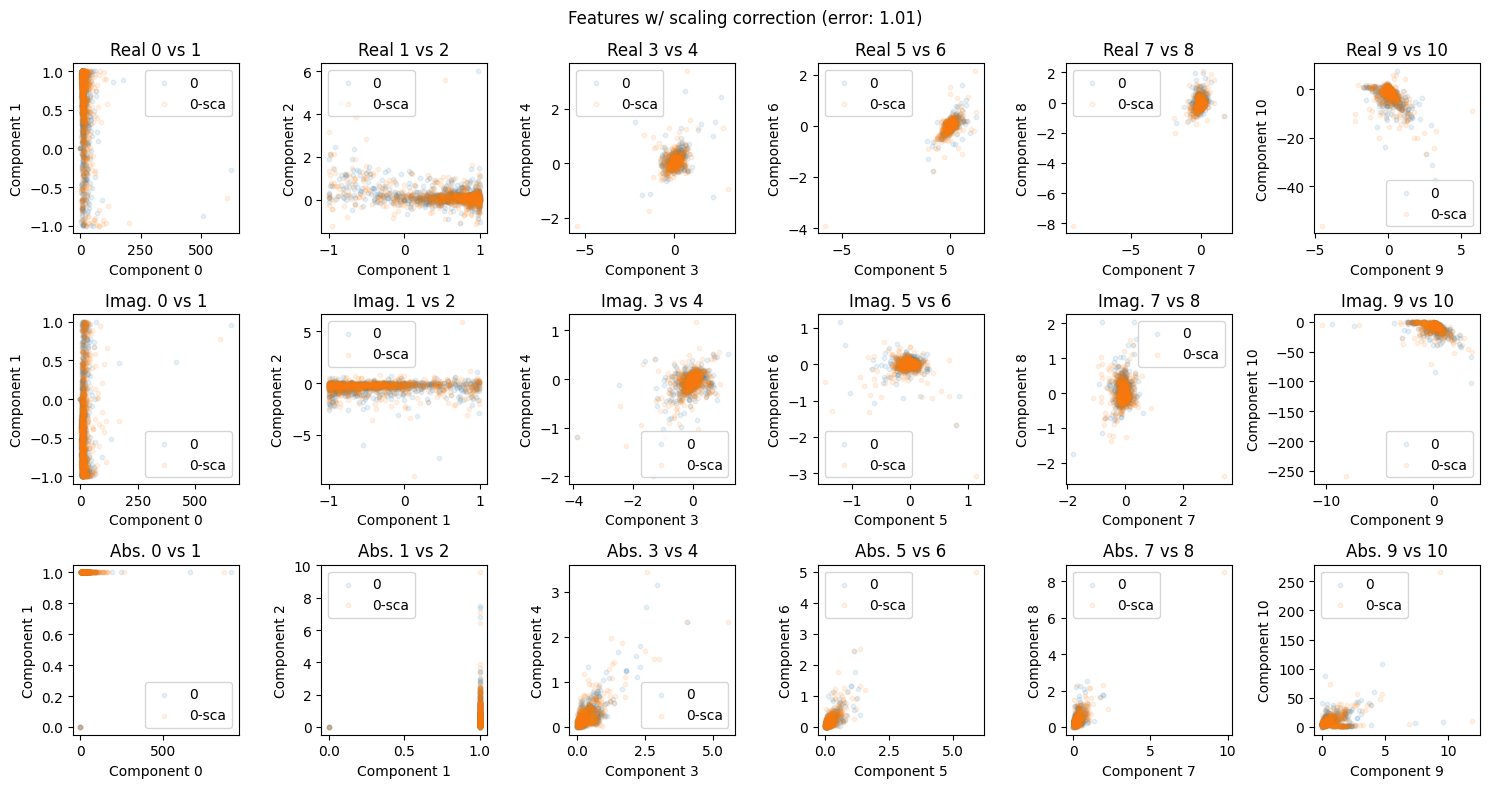

In [26]:
################################################################
############################ TEST ##############################
################################################################

test_2_3_4(
    scaling_invariant,
    find_contour,
    apply_scaling,
    compute_descriptor_padding,
    linear_interpolation,
    images_p_a,
    feat_t_a,
    feat_a,
)

---

# PART 3 - Other descriptors [8 pts]

## 3.1 Distance map (5 pts)

In this part, we will learn how to use a distance map as a feature descriptor.

- **Q1 (1 pt)**: To compute a distance map we first need a reference pattern. Complete the function `reference_pattern`. The function takes as input a list of images and computes the reference pattern as the average of all shapes.


In [27]:
def reference_pattern(imgs):
    """
    Compute the reference pattern for a given set of images. The reference pattern
    is estimated as the average of all images of the same pattern.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images

    Return
    ------
    pattern: np.ndarray (28, 28)
        Thresholded reference pattern that is the average of all shapes.
    """

    # Initialize pattern
    pattern = np.zeros((imgs[0].shape[0], imgs[0].shape[1])) # 28x28

    # ------------------
    # Your code here ...
    # ------------------

    pattern = np.mean(imgs, axis=0)
    
    return pattern

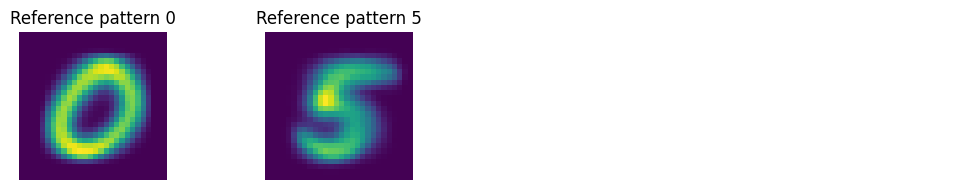

In [28]:
################################################################
############################ TEST ##############################
################################################################

pattern_a, pattern_b = test_3_1(reference_pattern, images_p_a, images_p_b)

- **Q2 (2 pts)**: The next part will be to compute a distance map from the generated pattern. By pre-computing the distance map we can speedup the inference time. Complete the function `compute_distance_map`. We expect the values of the map to represent the distances to the closest pattern contour. If needed, can take advantage of the functions you wrote in PART2 to detect and resample contours.


In [29]:
def compute_distance_map(pattern: np.ndarray):
    """
    Compute the distance map for the given pattern. The values of the map are computed as
    the distance to the closest pattern contour.

    Args
    ----
    pattern: np.ndarray (28, 28)
        Pattern to process

    Return
    ------
    distance_map: np.ndarray (28, 28)
        Distance map where each entry is the distance to the closest pattern contour (shortest
        distance to pattern)
    """

    # Initialize dummy values
    distance_map = np.zeros_like(pattern)

    # ------------------
    # Your code here ...
    # ------------------

    inf = 2*28*4
    epsilon = 0.2
    distance_map = np.where(pattern > (np.mean(pattern[pattern != 0])+epsilon), 0, inf).astype(np.uint8)
    adj = 3
    hyp = 4
    #plt.imshow(distance_map)

    X, Y = np.shape(distance_map)

    # Aller 
    for y in range(0, Y): # itère de 1 à (X-1) inclus
        for x in range(0, X):
            d = distance_map[x-1, y-1] if x!=0 and y!=0 else inf
            h = distance_map[x, y-1] if y!=0 else inf
            g = distance_map[x-1, y] if x!=0 else inf
            min_aller = min(d, h, g)

            if distance_map[x, y] > (min_aller + adj):
                if min_aller == d:
                    distance_map[x, y] = d+hyp
                else:
                    distance_map[x, y] = min_aller + adj

    # Retour
    for y in range(Y-1, -1, -1): # jusqu'à -1 nn inclus (donc 0), par steps de -1
        for x in range(X-1, -1, -1):
            d = distance_map[x+1, y+1] if x!=X-1 and y!=27 else inf
            b = distance_map[x, y+1] if y!=Y-1 else inf
            dr = distance_map[x+1, y] if x!=X-1 else inf
            min_retour = min(d, b, dr)
            
            if distance_map[x, y] > (min_retour + adj):
                if min_retour == d:
                    distance_map[x, y] = d+hyp
                else:
                    distance_map[x, y] = min_retour + adj

    
    return distance_map

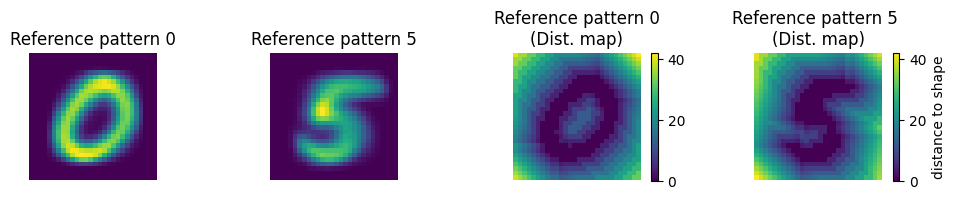

In [30]:
################################################################
############################ TEST ##############################
################################################################

map_a, map_b = test_3_1_2(compute_distance_map, pattern_a, pattern_b)

- **Q3 (2 pts)**: For the last part, implement the function `compute_distance` that uses the precomputed distance map to evaluate the distance to all images. Note that for each image you should return the average of distances. As before, for each digit, you can compute the contour and estimate the point-to-point distance by evaluating the distance map at the xy contour coordinates.


In [31]:
def compute_distance(imgs, d_map):
    """
    Compute the distances for each image with respect to the reference pattern using the precomputed
    distance map. The final distance is the average of all distances from the image's contour points
    to the reference pattern.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
    d_map: np.ndarray (28, 28)
        The precomputed distance map where each entry is the distance to the closest pattern contour
        (shortest distance to pattern)

    Return
    ------
    dist: np.ndarray (N, )
        Averaged distance to pattern for each input image.
    """

    # Default values
    dist = np.zeros(len(imgs))

    # ------------------
    # Your code here ...
    # ------------------
    
    mask = (imgs >= 1e-4).astype(np.float64)

    for n in range(len(imgs)):
        mask[n] *= d_map
        dist[n] = np.sum(mask)
        
    return dist

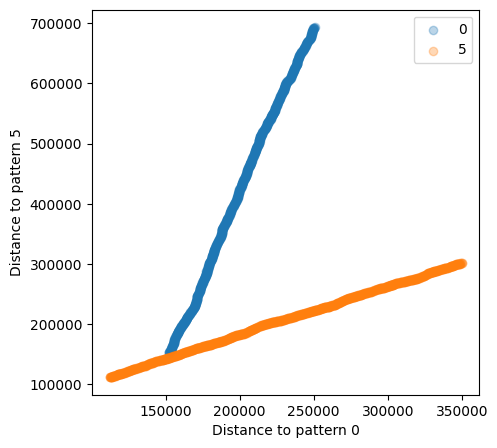

In [32]:
################################################################
############################ TEST ##############################
################################################################

test_3_1_3(compute_distance, images_p_a, images_p_b, map_a, map_b)

## 3.2 Others (3 pts)

For the last part of the lab, we will compute other various visual features.

- **Q1: (2 pts)**: Implement the function `compute_features` that estimates the digit's perimeter, area, compacity, and rectangularity. You can use the lecture to look for the definition of each feature. To help you with this task we strongly recommend using the `regionprops` ([doc](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops)) from scikit-image.
- **Q2: (1 pt)**: Which feature(s) seem(s) to show the best results to distinguish between both digits? (justify)
  - **Answer**: Our answers are based on the visualisation of : the graph from the test_3_2 ; the 0's and 5's shape ; a simple Fischer-criterion calculator.
  - Compacity : With no calculation we would have think that the feature that would distinguish the more between both digits would be the compacity. The 0's should obviously be very compact as their shape is close to the most compact shape possible : a disk.  At first, our result were very strange as both digits couldn't be diffrenciated with the four new descriptors. We understood that we should just "fill" the 0's to get a normal area value (and we made sure that we had no "maximal area", which would correspond to an image entirely fulfilled). This got us more expected results.

  - Rectangularity : Looking at the shape of the numbers, we could think that the descriptor that distinguishes the best could be the rectangularity, as a 5 "looks" a little like a rectangle, so the the circumscript rectangle of a 5 would be similar to the 5. This has been confirmed with the simple Fischer criterion calculator. But this turned out to be a coincidence ! Indeed, the rectangularity will compare the area pf the shape, and the area of the circumscript rectangle. We were just lucky that, the line of the 5 is not very wide which will give a small area and this will be divided by a bigger area (the rectangle's). So the rectangularity of a 5 is indeed way smaller than the rectangularity of a 0 (confirmed by the graph). Still, this is a good feature to distinguish 0s and 5s (confirmed by the Fischer crit.).
  
  - Area and Perimeter : We see on the graph perimeter/area that only one feature doesn't distinguish well the digits. But the combination of both descriptors does distinguish very good both categories. We created a parameter "z" = area/perimeter which should work better than its cousin the descriptor "compacity". It is due to : 
    - Both digits have very different slope for these 2 parameters (looking at the graphs). 
    - For both digits, the area "increases quicker" than the perimeter so squarring up the perimeter (which gives the compacity) will make both slopes more similar between each other

In [33]:
def fill_holes(img):
    mask = (img >= 1e-4).astype(np.uint8)
    
    flood = np.zeros_like(mask)
    stack = [(0, 0)]
    
    while stack:
        x, y = stack.pop()
        if x < 0 or x >= 28 or y < 0 or y >= 28:
            continue
        if flood[x, y] == 1 or mask[x, y] == 1:
            continue
        flood[x, y] = 1
        stack.extend([(x+1, y), (x-1, y), (x, y+1), (x, y-1)])
    
    filled = np.where(flood == 0, 1, mask)
    return filled

In [34]:
from skimage.measure import regionprops

In [35]:
def compute_features(imgs: np.ndarray):
    """
    Compute compacity for each input image.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images

    Return
    ------
    f_peri: np.ndarray (N,)
        Estimated perimeter length for each image
    f_area: np.ndarray (N,)
        Estimated area for each image
    f_comp: np.ndarray (N,)
        Estimated compacity for each image
    f_rect: np.ndarray (N,)
        Estimated rectangularity for each image
    """

    f_peri = np.zeros(len(imgs))
    f_area = np.zeros(len(imgs))
    f_comp = np.zeros(len(imgs))
    f_rect = np.zeros(len(imgs))
    z = np.zeros(len(imgs)) 
    


    for n in range(len(imgs)):
        props = regionprops(fill_holes(imgs[n]))[0]
        f_area[n] = props.area
        f_peri[n] = props.perimeter
        f_comp[n] = f_peri[n]*f_peri[n] / f_area[n]
        f_rect[n] = f_area[n] / props.area_bbox
        z[n] = f_area[n] / f_peri[n]
    return f_peri, f_area, f_comp, f_rect#, z   #"z" must be returned only if we want to run differentiate_0_5  
                                                #"z" must NOT be returned if we want to run test_3_2

## To run the test_3_2() : please make sure that compute_features() returns only: f_peri, f_area, f_comp, f_rect and NOT z

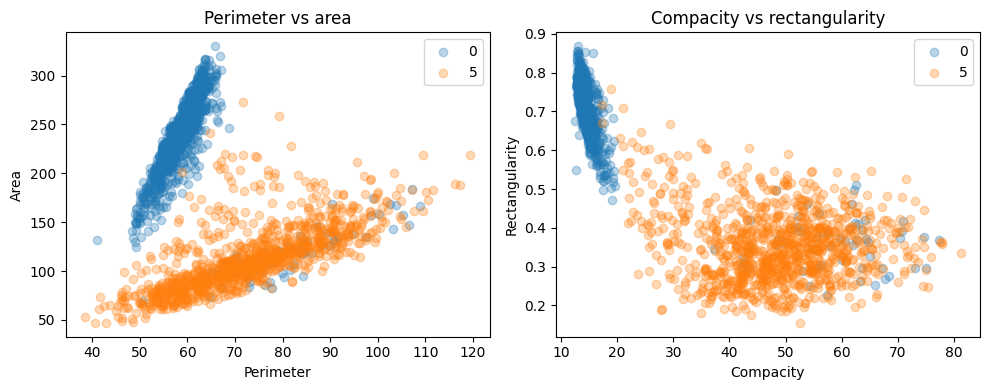

In [36]:
################################################################
############################ TEST ##############################
################################################################

test_3_2(compute_features, images_p_a, images_p_b)

## To run deferentiate_0_5() : please make sure that compute_features() return : f_peri, f_area, f_comp, f_rect and z

In [37]:
####### Please uncomment only if compute_features() returns also "z" #######


"""
def deferentiate_0_5():    
    
    fa_peri, fa_area, fa_comp, fa_rect, a = compute_features(images_p_a)
    fb_peri, fb_area, fb_comp, fb_rect, b = compute_features(images_p_b)

    # To see which features differentiate the best the digits
    features = {'perimeter': (fa_peri, fb_peri), 
                'area': (fa_area, fb_area),
                'compacity': (fa_comp, fb_comp),
                'rectangularity': (fa_rect, fb_rect),
                'z': (a, b)}

    for name, (fa, fb) in features.items():
        inter = (np.mean(fa) - np.mean(fb))**2
        intra = np.std(fa)**2 + np.std(fb)**2
        fisher = inter / intra
        print(f"{name}: {fisher:.4f}")
    
    return 0

_ = deferentiate_0_5()

"""

'\ndef deferentiate_0_5():    \n    \n    fa_peri, fa_area, fa_comp, fa_rect, a = compute_features(images_p_a)\n    fb_peri, fb_area, fb_comp, fb_rect, b = compute_features(images_p_b)\n\n    # To see which features differentiate the best the digits\n    features = {\'perimeter\': (fa_peri, fb_peri), \n                \'area\': (fa_area, fb_area),\n                \'compacity\': (fa_comp, fb_comp),\n                \'rectangularity\': (fa_rect, fb_rect),\n                \'z\': (a, b)}\n\n    for name, (fa, fb) in features.items():\n        inter = (np.mean(fa) - np.mean(fb))**2\n        intra = np.std(fa)**2 + np.std(fb)**2\n        fisher = inter / intra\n        print(f"{name}: {fisher:.4f}")\n    \n    return 0\n\n_ = deferentiate_0_5()\n\n'